# v04 — Cari Peluang Tambah Frekuensi Tanpa Turunkan Profit Factor

**Latar belakang (dari v03):** parameter terbaik grid search v03 (`MIN_SIGNAL_SCORE=11.0`,
`require_h1_alignment=True`) hasilnya profit factor 1.37 tapi cuma **2.1 trade/hari**. User memilih
menerima frekuensi rendah demi profit lebih pasti, tapi minta dicoba lagi cari peluang lain.

**Analisis funnel (kenapa trade jarang):**
- 71.6% candle lolos hard filter ADX/ATR dasar — **bukan ini bottleneck-nya**
- Dari situ, cuma **1.37%** yang capai `MIN_SIGNAL_SCORE=11` — skor 11 ada di **persentil 99** dari
  distribusi skor (median cuma 4.75, P90=8.98, P95=9.97, max=14.95) — **ini bottleneck utamanya**
- H1 filter memangkas lagi ~50% dari yang tersisa (1.37% -> 0.72%)

**Rencana eksperimen v04** (3 arah, semua diuji via grid search sistematis, bukan tebak manual):
1. **Turunkan MIN_SIGNAL_SCORE ke rentang 7.0-10.5** (P50-P95) — cari titik di mana frekuensi naik
   signifikan tapi profit factor masih > 1.2
2. **Variasi TP/SL ratio** — RR lebih kecil (mis. TP8/SL6, RR 1:1.33) bisa naikkan win rate meski
   avg win lebih kecil; RR lebih besar (TP16/SL6) sebaliknya
3. **Variasi MAX_HOLD_CANDLES** — hold lebih pendek = modal lebih cepat available buat trade baru
   (turnover lebih tinggi), meski tiap trade individual mungkin sedikit kurang optimal

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from app.utils.signals import generate_signal

STRATEGY_NAME = "m5_scalping"
VERSION = "v04"

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME
EXPORT_DIR = PROJECT_ROOT / "dataset" / "exports" / STRATEGY_NAME / VERSION
PROCESSED_OUT_DIR = PROCESSED_DIR / VERSION
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Load dataset M5 + H1 (sama seperti v02/v03)

In [2]:
df = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_m5_full_indicators.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

df_h1 = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_h1_full_indicators.csv")
df_h1["datetime"] = pd.to_datetime(df_h1["datetime"])
df_h1 = df_h1.sort_values("datetime").reset_index(drop=True)

df_h1_shifted = df_h1.copy()
df_h1_shifted["h1_available_at"] = df_h1_shifted["datetime"] + pd.Timedelta(hours=1)
h1_value_cols = [c for c in df_h1_shifted.columns if c != "h1_available_at"]
df_h1_shifted = df_h1_shifted[["h1_available_at", *h1_value_cols]].rename(
    columns={c: f"h1_{c}" for c in h1_value_cols}
)

df = pd.merge_asof(
    df.sort_values("datetime"),
    df_h1_shifted.sort_values("h1_available_at"),
    left_on="datetime",
    right_on="h1_available_at",
    direction="backward",
)

BACKTEST_START = "2025-01-01"
df_bt = df[df["datetime"] >= BACKTEST_START].reset_index(drop=True)
print("Baris untuk backtest:", len(df_bt))

Baris untuk backtest: 107336


## 2. Fungsi reusable (sama pola dgn v03, tapi TP/SL/MAX_HOLD jadi parameter backtest)

In [3]:
INITIAL_EQUITY = 100.0
RISK_PCT = 0.01
CONTRACT_SIZE = 100.0
MIN_LOT = 0.01
LOT_STEP = 0.01
SPREAD_POINTS = 0.30
ADX_MIN = 18.0
ATR_MIN_PCT = 0.03

RAW_INDICATOR_COLUMNS = [c for c in df_bt.columns if c not in ("timestamp", "datetime")]


def calc_lot(equity: float, risk_pct: float, sl_distance: float) -> float:
    if sl_distance <= 0 or equity <= 0:
        return MIN_LOT
    risk_amount = equity * risk_pct
    raw_lot = risk_amount / (sl_distance * CONTRACT_SIZE)
    lot = math.floor(raw_lot / LOT_STEP) * LOT_STEP
    return max(round(lot, 2), MIN_LOT)


def apply_signals(df_in: pd.DataFrame, min_signal_score: float, require_h1_alignment: bool) -> pd.DataFrame:
    directions = np.empty(len(df_in), dtype=object)
    scores = np.zeros(len(df_in))
    for pos, (_, row) in enumerate(df_in.iterrows()):
        result = generate_signal(row, min_signal_score, ADX_MIN, ATR_MIN_PCT, require_h1_alignment)
        directions[pos] = result.direction
        scores[pos] = result.final_score
    out = df_in.copy()
    out["signal_direction"] = directions
    out["signal_score"] = scores
    return out


def run_backtest(df_signals: pd.DataFrame, tp_points: float, sl_points: float,
                  max_hold_candles: int, save_full_log: bool = False) -> tuple[pd.DataFrame, list[float]]:
    trades = []
    equity = INITIAL_EQUITY
    equity_curve = [equity]
    i = 0
    n = len(df_signals)

    while i < n:
        row = df_signals.iloc[i]
        direction = row["signal_direction"]

        if direction == "WAIT":
            i += 1
            continue

        entry_price = row["close"] + (SPREAD_POINTS if direction == "BUY" else -SPREAD_POINTS)
        entry_time = row["datetime"]

        if direction == "BUY":
            tp_price = entry_price + tp_points
            sl_price = entry_price - sl_points
        else:
            tp_price = entry_price - tp_points
            sl_price = entry_price + sl_points

        lot = calc_lot(equity, RISK_PCT, sl_points)
        equity_before = equity

        exit_price = None
        exit_time = None
        exit_reason = None

        for j in range(i + 1, min(i + 1 + max_hold_candles, n)):
            candle = df_signals.iloc[j]
            hit_tp = candle["high"] >= tp_price if direction == "BUY" else candle["low"] <= tp_price
            hit_sl = candle["low"] <= sl_price if direction == "BUY" else candle["high"] >= sl_price

            if hit_sl:
                exit_price, exit_time, exit_reason = sl_price, candle["datetime"], "SL"
                break
            if hit_tp:
                exit_price, exit_time, exit_reason = tp_price, candle["datetime"], "TP"
                break

        if exit_price is None:
            last_idx = min(i + max_hold_candles, n - 1)
            last_candle = df_signals.iloc[last_idx]
            exit_price, exit_time, exit_reason = last_candle["close"], last_candle["datetime"], "TIMEOUT"
            next_i = last_idx + 1
            hold_candles = last_idx - i
        else:
            next_i = j + 1
            hold_candles = j - i

        price_move = (exit_price - entry_price) if direction == "BUY" else (entry_price - exit_price)
        pnl = price_move * lot * CONTRACT_SIZE
        equity += pnl
        equity_curve.append(equity)

        trade_record = {
            "entry_time": entry_time, "exit_time": exit_time, "direction": direction,
            "entry_price": entry_price, "exit_price": exit_price, "tp_price": tp_price, "sl_price": sl_price,
            "lot": lot, "hold_candles": hold_candles, "pnl": pnl,
            "result": "WIN" if pnl > 0 else "LOSS", "exit_reason": exit_reason,
            "signal_score": row["signal_score"], "equity_before": equity_before, "equity_after": equity,
        }
        if save_full_log:
            for col in RAW_INDICATOR_COLUMNS:
                trade_record[f"ind_{col}"] = row[col]

        trades.append(trade_record)
        i = next_i

    return pd.DataFrame(trades), equity_curve


def evaluate(trades: pd.DataFrame, initial_equity: float) -> dict:
    if trades.empty:
        return {"total_trades": 0}

    wins = trades[trades["pnl"] > 0]
    losses = trades[trades["pnl"] <= 0]
    gross_profit = wins["pnl"].sum()
    gross_loss = losses["pnl"].sum()
    final_equity = trades["equity_after"].iloc[-1]

    equity_series = pd.Series([initial_equity] + trades["equity_after"].tolist())
    running_max = equity_series.cummax()
    drawdown = (equity_series - running_max) / running_max * 100

    trades = trades.copy()
    trades["trade_date"] = trades["entry_time"].dt.date
    daily_pnl = trades.groupby("trade_date")["pnl"].sum()

    return {
        "total_trades": len(trades),
        "win_rate_pct": round(len(wins) / len(trades) * 100, 2),
        "profit_factor": round(gross_profit / abs(gross_loss), 2) if gross_loss != 0 else float("inf"),
        "net_pnl": round(gross_profit + gross_loss, 2),
        "final_equity": round(final_equity, 2),
        "max_drawdown_pct": round(drawdown.min(), 2),
        "min_equity": round(equity_series.min(), 2),
        "expectancy_per_trade": round(trades["pnl"].mean(), 3),
        "trading_days": daily_pnl.shape[0],
        "avg_daily_pnl": round(daily_pnl.mean(), 2),
        "avg_trades_per_day": round(len(trades) / daily_pnl.shape[0], 2) if daily_pnl.shape[0] else 0,
    }

## 3. Grid search luas: MIN_SIGNAL_SCORE x TP/SL x MAX_HOLD (dengan H1 filter tetap aktif)

H1 filter dipertahankan aktif di semua kombinasi (v03 membuktikan ini penting untuk kualitas).
Yang divariasikan: threshold skor (lebih rendah dari v03), rasio TP/SL, dan lama hold maksimum.

In [4]:
score_candidates = [7.0, 8.0, 9.0, 10.0]
tp_sl_candidates = [(8.0, 6.0), (12.0, 6.0), (16.0, 6.0), (12.0, 8.0)]  # (TP, SL) dalam poin
max_hold_candidates = [12, 24]  # 1 jam vs 2 jam

grid_results = []

# Precompute sinyal per score candidate (supaya tidak ulang generate_signal untuk tiap TP/SL/MAX_HOLD)
signal_cache = {}
for min_score in score_candidates:
    print(f"Generating signals for score>={min_score}...")
    signal_cache[min_score] = apply_signals(df_bt, min_score, require_h1_alignment=True)

for min_score in score_candidates:
    df_signals = signal_cache[min_score]
    for tp, sl in tp_sl_candidates:
        for max_hold in max_hold_candidates:
            trades, _ = run_backtest(df_signals, tp, sl, max_hold, save_full_log=False)
            metrics = evaluate(trades, INITIAL_EQUITY)
            metrics.update({
                "min_signal_score": min_score, "tp_points": tp, "sl_points": sl,
                "rr_ratio": round(tp / sl, 2), "max_hold_candles": max_hold,
            })
            grid_results.append(metrics)

grid_df = pd.DataFrame(grid_results)
print(f"\nTotal kombinasi diuji: {len(grid_df)}")
# Filter hanya yang punya cukup banyak trade (biar statistik tidak terlalu noisy) dan PF > 1
grid_df_valid = grid_df[(grid_df["total_trades"] >= 100) & (grid_df["profit_factor"] > 1.0)]
grid_df_valid = grid_df_valid.sort_values(["avg_trades_per_day", "profit_factor"], ascending=[False, False])
grid_df_valid.head(20)

Generating signals for score>=7.0...


Generating signals for score>=8.0...


Generating signals for score>=9.0...


Generating signals for score>=10.0...



Total kombinasi diuji: 32


,total_trades,win_rate_pct,profit_factor,net_pnl,final_equity,max_drawdown_pct,min_equity,expectancy_per_trade,trading_days,avg_daily_pnl,avg_trades_per_day,min_signal_score,tp_points,sl_points,rr_ratio,max_hold_candles
0,3768,45.01,1.03,308.21,408.21,-106.73,-39.13,0.082,431,0.72,8.74,7.0,8.0,6.0,1.33,12
1,3482,44.74,1.02,246.69,346.69,-113.84,-77.75,0.071,430,0.57,8.10,7.0,8.0,6.0,1.33,24
2,3393,41.06,1.07,708.33,808.33,-52.07,74.54,0.209,431,1.64,7.87,7.0,12.0,6.0,2.00,12
4,3209,39.79,1.12,1243.71,1343.71,-41.68,74.54,0.388,429,2.90,7.48,7.0,16.0,6.0,2.67,12
6,3199,46.73,1.12,1308.50,1408.50,-62.81,70.54,0.409,431,3.04,7.42,7.0,12.0,8.0,1.50,12
3,3026,38.57,1.06,593.90,693.90,-64.91,81.77,0.196,430,1.38,7.04,7.0,12.0,6.0,2.00,24
8,2956,46.08,1.05,438.00,538.00,-79.46,71.76,0.148,422,1.04,7.00,8.0,8.0,6.0,1.33,12
9,2750,45.71,1.06,510.46,610.46,-72.12,83.83,0.186,421,1.21,6.53,8.0,8.0,6.0,1.33,24
7,2774,45.96,1.12,1351.72,1451.72,-39.89,79.77,0.487,430,3.14,6.45,7.0,12.0,8.0,1.50,24
5,2739,36.36,1.11,1121.69,1221.69,-40.32,81.77,0.410,428,2.62,6.40,7.0,16.0,6.0,2.67,24


## 4. Bandingkan trade-off: profit factor vs frekuensi trading

Scatter plot semua kombinasi (termasuk yg PF<=1) untuk lihat keseluruhan trade-off, baru pilih titik
yang masuk akal (PF cukup tinggi DAN frekuensi lebih baik dari v03's 2.1 trade/hari).

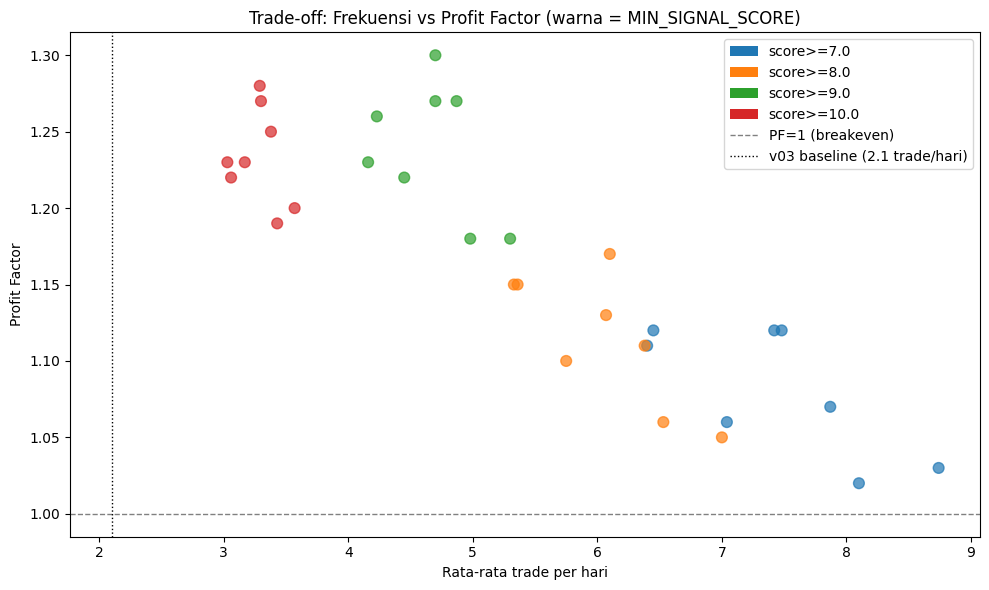

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = grid_df["min_signal_score"].map({7.0: "tab:blue", 8.0: "tab:orange", 9.0: "tab:green", 10.0: "tab:red"})
scatter = ax.scatter(grid_df["avg_trades_per_day"], grid_df["profit_factor"], c=colors, s=60, alpha=0.7)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="PF=1 (breakeven)")
ax.axvline(2.1, color="black", linestyle=":", linewidth=1, label="v03 baseline (2.1 trade/hari)")
ax.set_xlabel("Rata-rata trade per hari")
ax.set_ylabel("Profit Factor")
ax.set_title("Trade-off: Frekuensi vs Profit Factor (warna = MIN_SIGNAL_SCORE)")

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=f"score>={s}") for s, c in
                [(7.0,"tab:blue"),(8.0,"tab:orange"),(9.0,"tab:green"),(10.0,"tab:red")]]
ax.legend(handles=legend_elems + [ax.lines[0], ax.lines[1]] if ax.lines else legend_elems)
plt.tight_layout()
plt.savefig(EXPORT_DIR / "tradeoff_scatter.png", dpi=120)
plt.show()

## 5. Pilih kombinasi terbaik & jalankan backtest final dengan log lengkap

In [6]:
# Kandidat "lebih baik dari v03": PF >= 1.2 (masih sehat) DAN trade/hari > 2.1 (baseline v03)
candidates = grid_df[(grid_df["profit_factor"] >= 1.2) & (grid_df["avg_trades_per_day"] > 2.1)]
candidates = candidates.sort_values("avg_trades_per_day", ascending=False)
print(f"Kandidat lebih baik dari v03 (PF>=1.2 & trade/hari>2.1): {len(candidates)}")
candidates.head(10)

Kandidat lebih baik dari v03 (PF>=1.2 & trade/hari>2.1): 13


,total_trades,win_rate_pct,profit_factor,net_pnl,final_equity,max_drawdown_pct,min_equity,expectancy_per_trade,trading_days,avg_daily_pnl,avg_trades_per_day,min_signal_score,tp_points,sl_points,rr_ratio,max_hold_candles
18,1939,44.51,1.27,1601.34,1701.34,-37.02,86.98,0.826,398,4.02,4.87,9.0,12.0,6.0,2.00,12
20,1865,42.57,1.30,1914.30,2014.30,-48.92,86.98,1.026,397,4.82,4.70,9.0,16.0,6.0,2.67,12
22,1869,49.97,1.27,1613.39,1713.39,-48.83,87.46,0.863,398,4.05,4.70,9.0,12.0,8.0,1.50,12
19,1771,41.78,1.22,1326.52,1426.52,-33.53,80.21,0.749,398,3.33,4.45,9.0,12.0,6.0,2.00,24
23,1684,48.16,1.26,1612.92,1712.92,-55.13,86.27,0.958,398,4.05,4.23,9.0,12.0,8.0,1.50,24
21,1652,38.32,1.23,1354.70,1454.70,-39.87,80.21,0.820,397,3.41,4.16,9.0,16.0,6.0,2.67,24
24,1275,48.31,1.20,677.45,777.45,-22.00,99.00,0.531,357,1.90,3.57,10.0,8.0,6.0,1.33,12
26,1208,43.96,1.25,893.52,993.52,-18.74,99.00,0.740,357,2.50,3.38,10.0,12.0,6.0,2.00,12
30,1177,49.28,1.27,1005.90,1105.90,-24.78,99.00,0.855,357,2.82,3.30,10.0,12.0,8.0,1.50,12
28,1171,42.19,1.28,999.83,1099.83,-16.02,99.00,0.854,356,2.81,3.29,10.0,16.0,6.0,2.67,12


In [7]:
if len(candidates) > 0:
    best = candidates.iloc[0]
else:
    # Fallback: kalau tidak ada yang PF>=1.2, ambil PF tertinggi di antara yg trade/hari > 2.1
    fallback = grid_df[grid_df["avg_trades_per_day"] > 2.1].sort_values("profit_factor", ascending=False)
    best = fallback.iloc[0] if len(fallback) else grid_df.sort_values("profit_factor", ascending=False).iloc[0]

MIN_SIGNAL_SCORE = float(best["min_signal_score"])
TP_POINTS = float(best["tp_points"])
SL_POINTS = float(best["sl_points"])
MAX_HOLD_CANDLES = int(best["max_hold_candles"])

print(f"Parameter terpilih: score>={MIN_SIGNAL_SCORE}, TP={TP_POINTS}, SL={SL_POINTS}, "
      f"MAX_HOLD={MAX_HOLD_CANDLES} candle, H1 filter aktif")

df_signals_final = signal_cache[MIN_SIGNAL_SCORE]
trades_df, equity_curve = run_backtest(df_signals_final, TP_POINTS, SL_POINTS, MAX_HOLD_CANDLES, save_full_log=True)

metrics = evaluate(trades_df, INITIAL_EQUITY)
for k, v in metrics.items():
    print(f"{k:25s}: {v}")

Parameter terpilih: score>=9.0, TP=12.0, SL=6.0, MAX_HOLD=12 candle, H1 filter aktif


total_trades             : 1939
win_rate_pct             : 44.51
profit_factor            : 1.27
net_pnl                  : 1601.34
final_equity             : 1701.34
max_drawdown_pct         : -37.02
min_equity               : 86.98
expectancy_per_trade     : 0.826
trading_days             : 398
avg_daily_pnl            : 4.02
avg_trades_per_day       : 4.87


## 6. Bandingkan v03 vs v04 secara langsung

In [8]:
v03_metrics = {
    "total_trades": 556, "win_rate_pct": 44.6, "profit_factor": 1.37, "net_pnl": 646.2,
    "max_drawdown_pct": -33.13, "avg_daily_pnl": 2.44, "avg_trades_per_day": 2.1,
}

comparison = pd.DataFrame({"v03 (baseline)": v03_metrics, "v04 (kandidat baru)":
                            {k: metrics.get(k) for k in v03_metrics}})
comparison

,v03 (baseline),v04 (kandidat baru)
total_trades,556.00,1939.00
win_rate_pct,44.60,44.51
profit_factor,1.37,1.27
net_pnl,646.20,1601.34
max_drawdown_pct,-33.13,-37.02
avg_daily_pnl,2.44,4.02
avg_trades_per_day,2.10,4.87


## 7. Grafik equity curve & evaluasi target harian

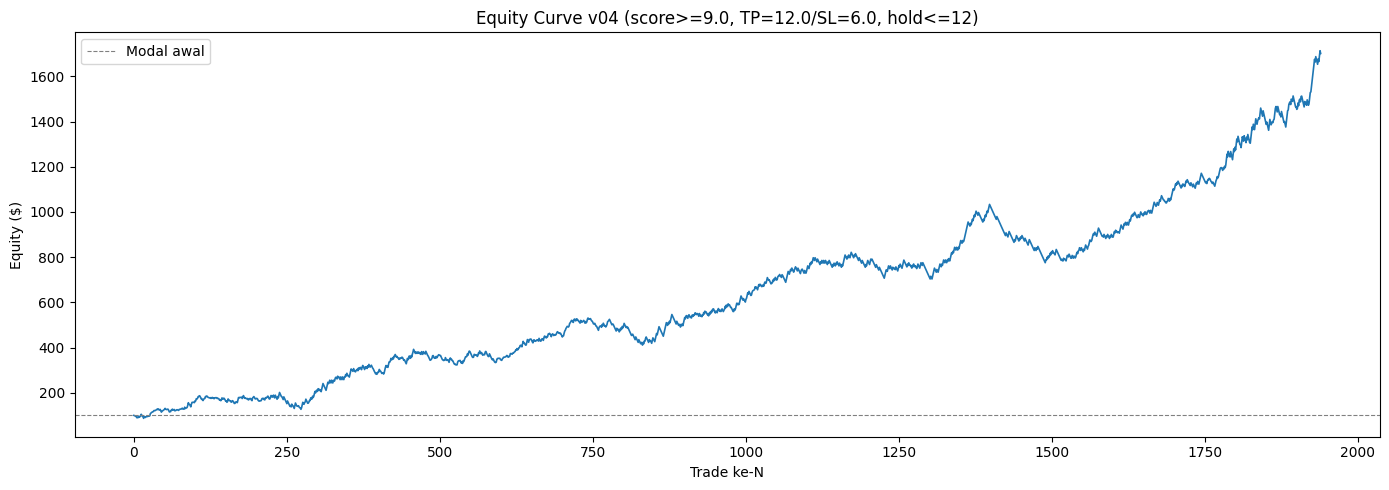

In [9]:
fig, ax = plt.subplots()
ax.plot(equity_curve, linewidth=1.2)
ax.axhline(INITIAL_EQUITY, color="gray", linestyle="--", linewidth=0.8, label="Modal awal")
ax.set_title(f"Equity Curve v04 (score>={MIN_SIGNAL_SCORE}, TP={TP_POINTS}/SL={SL_POINTS}, hold<={MAX_HOLD_CANDLES})")
ax.set_xlabel("Trade ke-N")
ax.set_ylabel("Equity ($)")
ax.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "equity_curve.png", dpi=120)
plt.show()

In [10]:
trades_df["trade_date"] = trades_df["entry_time"].dt.date
daily_pnl = trades_df.groupby("trade_date")["pnl"].sum()

for target in [10.0, 5.0, 2.0, 1.0]:
    days_hit = (daily_pnl >= target).sum()
    pct_hit = days_hit / len(daily_pnl) * 100
    print(f"Target ${target:>5.1f}/hari: tercapai {days_hit:4d} dari {len(daily_pnl)} hari ({pct_hit:5.1f}%)")

print()
print(f"Rata-rata PnL harian : ${daily_pnl.mean():.2f}")
print(f"Equity minimum       : ${trades_df['equity_after'].min():.2f} (dari modal awal $100)")

Target $ 10.0/hari: tercapai  119 dari 398 hari ( 29.9%)
Target $  5.0/hari: tercapai  164 dari 398 hari ( 41.2%)
Target $  2.0/hari: tercapai  189 dari 398 hari ( 47.5%)
Target $  1.0/hari: tercapai  199 dari 398 hari ( 50.0%)

Rata-rata PnL harian : $4.02
Equity minimum       : $86.98 (dari modal awal $100)


## 8. Simpan hasil

In [11]:
trades_df.to_csv(PROCESSED_OUT_DIR / "trade_log_full.csv", index=False)

summary_cols = [c for c in trades_df.columns if not c.startswith("ind_")]
trades_df[summary_cols].to_csv(EXPORT_DIR / "trades.csv", index=False)

grid_df.to_csv(EXPORT_DIR / "grid_search_results.csv", index=False)

with open(EXPORT_DIR / "metrics.txt", "w") as f:
    f.write(f"Backtest v04 — XAUUSD M5 — periode {BACKTEST_START} s/d {df_bt['datetime'].max()}\n")
    f.write(f"Parameter TERPILIH: MIN_SIGNAL_SCORE={MIN_SIGNAL_SCORE}, TP={TP_POINTS}, SL={SL_POINTS}, "
            f"MAX_HOLD={MAX_HOLD_CANDLES}, require_h1_alignment=True\n")
    f.write(f"ADX_MIN={ADX_MIN}, ATR_MIN_PCT={ATR_MIN_PCT}, RISK_PCT={RISK_PCT}\n\n")
    for k, v in metrics.items():
        f.write(f"{k}: {v}\n")

print("Log lengkap:", PROCESSED_OUT_DIR / "trade_log_full.csv")
print("Ringkasan & grafik:", EXPORT_DIR)
for f in sorted(EXPORT_DIR.glob("*")):
    print(" -", f.name)

Log lengkap: D:\Projects\robot-scalping\dataset\processed\m5_scalping\v04\trade_log_full.csv
Ringkasan & grafik: D:\Projects\robot-scalping\dataset\exports\m5_scalping\v04
 - equity_curve.png
 - grid_search_results.csv
 - metrics.txt
 - tradeoff_scatter.png
 - trades.csv
